# Does the World Series pick next year's stock market? ⚾📉
### A baseball cousin of the Super Bowl Indicator — and it fails the same way

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

Every October, someone in financial media half-jokingly asks whether the World Series winner tells you anything about next year's stock market — the same way the **Super Bowl Indicator** claims the NFC/AFC does. There are even two flavors: does the *league* (American vs National) matter, or does it just come down to whether **a New York team wins** — Wall Street's hometown club, riding high?

We test both. Neither survives contact with the correct baseline.

> 📓 **Plain-language layer.** Want the *t*-stats, the permutation test and the coin-flip math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 76 World Series champions hardcoded from MLB's own postseason record, 1950→2025 (1994's players'-strike gap named, not papered over). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from world_series_effect import data, strategy as st

WS = data.ws_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    GSPC = data.load_real()
    ANN = data.annual_returns(GSPC)
    EV = st.build_events(WS, ANN)
else:
    GSPC = ANN = EV = None
print("real cache present:", HAVE_REAL, "| played World Series:", len(WS),
      "| scoreable events:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': 1950, 'end': 2025, 'n_played': 75, 'n_events': 74, 'n_al': 39, 'n_nl': 35, 'n_ny': 19, 'n_nonny': 55, 'uncond_up_pct': 73.0, 'nl_mean_bull': 11.21, 'nl_mean_bear': 7.16, 'nl_contrast': 4.05, 'nl_welch_t': 1.07, 'nl_perm_p': 0.2955, 'nl_hit': 52.7, 'nl_hit_lo': 41.5, 'nl_hit_hi': 63.7, 'nl_binom_p': 0.3675, 'nl_coin_p': 0.7275, 'ny_mean_bull': 8.02, 'ny_mean_bear': 9.43, 'ny_contrast': -1.41, 'ny_welch_t': -0.33, 'ny_perm_p': 0.7512, 'ny_hit': 39.2, 'ny_hit_lo': 28.9, 'ny_hit_hi': 50.6, 'ny_binom_p': 0.5896, 'ny_coin_p': 0.0805, 'bah_ann': 7.75, 'nl_strat_ann': 4.68, 'nl_strat_adv': -3.06, 'nl_n_held': 35, 'ny_strat_ann': 1.73, 'ny_strat_adv': -6.01, 'ny_n_held': 19, 'syn_null_mean': 0.09, 'syn_null_sd': 0.88, 'syn_null_fire': 0, 'syn_boost': 10.0, 'syn_planted_t': 3.01, 'syn_bull_mean': 17.68, 'syn_bear_mean': 5.78, 'fp_gspc': '50410c20273a'}


real cache present: True | played World Series: 75 | scoreable events: 74


## The answer first

| Question | Answer |
|---|---|
| Does the champion's league predict next year? | **No.** NL-preceded years averaged **+11.2%**, AL-preceded years **+7.2%** — a gap that looks real until you check the statistics: *t* = **1.07** (the bar is 2), and a random relabeling produces a gap this big **30% of the time**. |
| Does "a New York team wins" predict a good year? | **No — and it doesn't even point the right way.** NY-preceded years averaged **+8.0%** vs **+9.4%** for everyone else — the hometown story runs backwards in this sample. |
| Does either omen beat the market's own habit of going up? | **No.** The S&P rose in **73%** of all years in the sample regardless of who won the World Series — and the league-omen's hit rate (53%) and city-omen's hit rate (39%) are both *below* that baseline. |
| Can you trade it? | **No.** Sitting in cash whenever the omen says "bearish" costs you **3.1 to 6.0 percentage points a year** versus just staying invested — before a single dollar of trading cost. |

> There's a champion every year. The market goes up most years anyway. Everything else is a mascot.

## 1 · The claim

> *"When a National League team wins the World Series, stocks do well the following year; when an American League team wins, they don't — the same 'omen' logic as the Super Bowl Indicator (NFC good, AFC bad). And really, isn't it just about New York? When the Yankees (or Mets, or the old Brooklyn Dodgers) win it all, doesn't Wall Street's own backyard team winning mean good times are coming?"*

Unlike this desk's [FOMC vol-crush study](../../637-fomc-vol-crush/), which has a one-sentence causal mechanism (event-premium expiry), **nobody has ever proposed a reason** the World Series' league or host city should move the S&P. That's not disqualifying on its own — folklore doesn't need a mechanism to be tested — but it's worth naming up front: if this turns out to be a mirage, there's no theory to salvage.

## 2 · So what?

If real, this would be a free, public, zero-look-ahead signal: the World Series ends by early November, weeks before you'd need to act on a January 1 entry. No insider information, no complex model — just watch the box score. That's exactly why it's worth testing seriously rather than dismissing on priors: cheap, testable claims deserve the same rigor as expensive ones. And if it's *not* real, it's a clean teaching example of how a coincidence gets dressed up as an omen.

## 3 · How would we even know?

- **The calendar.** All **75** World Series actually played from 1950 to 2025 (1994 was cancelled by the players' strike — named, not imputed), hardcoded from MLB's own postseason record.
- **The comparison.** Each champion's league (AL/NL) and hometown (New York or not) against the S&P 500's return the *following* calendar year — **74** scoreable pairs in total.
- **The correct baseline.** The S&P doesn't split its years 50/50 — it goes up about **73%** of the time regardless. Any "predicts bullish" signal has to beat *that*, not a coin flip. Testing against 50% is the single most common mistake in these write-ups.
- **The luck check.** Shuffle which seasons count as "National League" 20,000 times — how often does a random relabeling produce a gap this large?
- **The trade check.** Hold the S&P only in years the omen calls bullish, sit in cash otherwise — does that beat just staying invested?

## 4 · The teardown — let's actually look

**First, the league omen.** Average next-year S&P return after an NL vs AL champion.

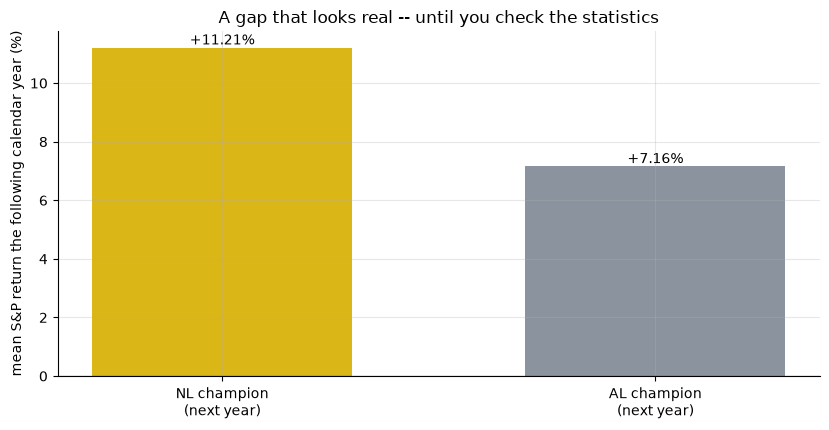

NL-preceded +11.21%   AL-preceded +7.16%


In [2]:
if HAVE_REAL:
    bull_nl = (EV['league'] == 'NL').to_numpy()
    s = st.omen_stats(EV, bull_nl)
    mb, mr = s['mean_bull_pct'], s['mean_bear_pct']
else:
    mb, mr = R['nl_mean_bull'], R['nl_mean_bear']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['NL champion\n(next year)','AL champion\n(next year)'], [mb, mr],
       color=[AMBER, GREY], width=.6)
for i,v in enumerate([mb, mr]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.axhline(R['uncond_up_pct']*0 , c='k', lw=0)  # keep axis tidy
ax.set_ylabel('mean S&P return the following calendar year (%)')
ax.set_title('A gap that looks real -- until you check the statistics')
plt.tight_layout(); plt.show()
print(f'NL-preceded {mb:+.2f}%   AL-preceded {mr:+.2f}%')

A **+4.0 percentage-point** gap, in the claimed direction. But the Welch *t* is only **1.07** — the desk's bar is 2 — and a random-relabeling test says a gap this size shows up **30% of the time** by pure chance. That's not a signal; that's 35 vs 39 draws from the same noisy bucket.

**Now the base-rate trap** — the number that actually kills the omen.

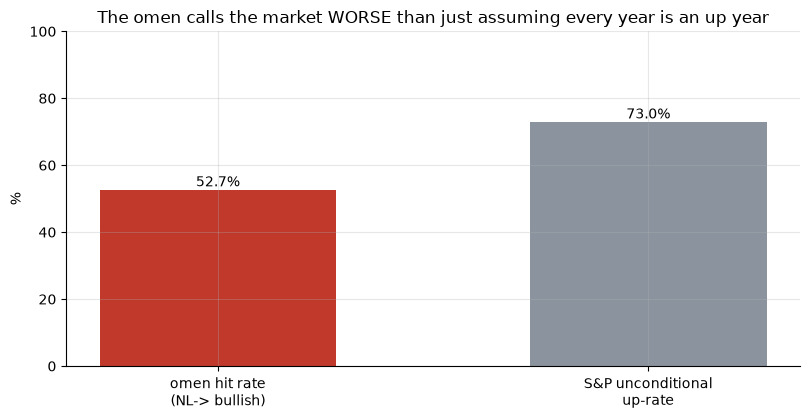

omen hit rate 52.7%   unconditional up-rate 73.0%


In [3]:
if HAVE_REAL:
    hit, base = s['hit_rate_pct'], s['uncond_up_pct']
else:
    hit, base = R['nl_hit'], R['uncond_up_pct']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['omen hit rate\n(NL-> bullish)','S&P unconditional\nup-rate'], [hit, base],
       color=[RED, GREY], width=.55)
for i,v in enumerate([hit, base]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylim(0, 100)
ax.set_ylabel('%')
ax.set_title('The omen calls the market WORSE than just assuming every year is an up year')
plt.tight_layout(); plt.show()
print(f'omen hit rate {hit:.1f}%   unconditional up-rate {base:.1f}%')

The S&P is up in about **73%** of all years regardless of baseball. The league omen's hit rate is only **52.7%** — meaning "trust the omen" calls the market's direction *less* accurately than simply assuming every year will be an up year, which it usually is anyway. This is the exact trap the Super Bowl Indicator falls into (see [study 158](../../158-super-bowl/)) — testing against a 50% coin instead of the market's real bias makes any "predict up" signal look prescient. It isn't.

**Now the city variant** — does it at least point the right way?

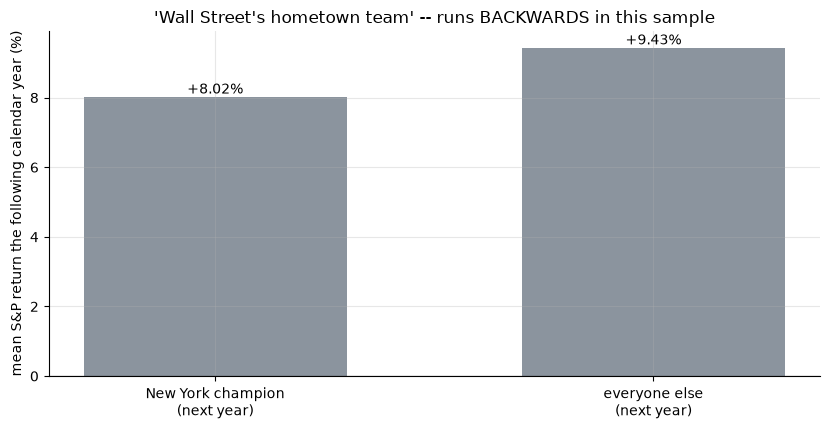

NY-preceded +8.02%   everyone else +9.43%


In [4]:
if HAVE_REAL:
    bull_ny = EV['is_ny'].to_numpy()
    s2 = st.omen_stats(EV, bull_ny)
    mb2, mr2 = s2['mean_bull_pct'], s2['mean_bear_pct']
else:
    mb2, mr2 = R['ny_mean_bull'], R['ny_mean_bear']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['New York champion\n(next year)','everyone else\n(next year)'], [mb2, mr2],
       color=[GREY, GREY], width=.6)
for i,v in enumerate([mb2, mr2]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean S&P return the following calendar year (%)')
ax.set_title("'Wall Street's hometown team' -- runs BACKWARDS in this sample")
plt.tight_layout(); plt.show()
print(f'NY-preceded {mb2:+.2f}%   everyone else {mr2:+.2f}%')

No — a New York title is followed by **+8.0%** on average, *worse* than the **+9.4%** everyone else gets. The pinstriped "hometown of Wall Street" story is exactly backwards on this tape, even before checking significance (it isn't significant either — the quants notebook has the numbers). Sixteen Yankee/Mets/Giants/Dodgers titles clustered in some strong-market decades and some weak ones; the eye sees a pattern where the arithmetic finds noise.

**Finally, could you actually trade either omen?**

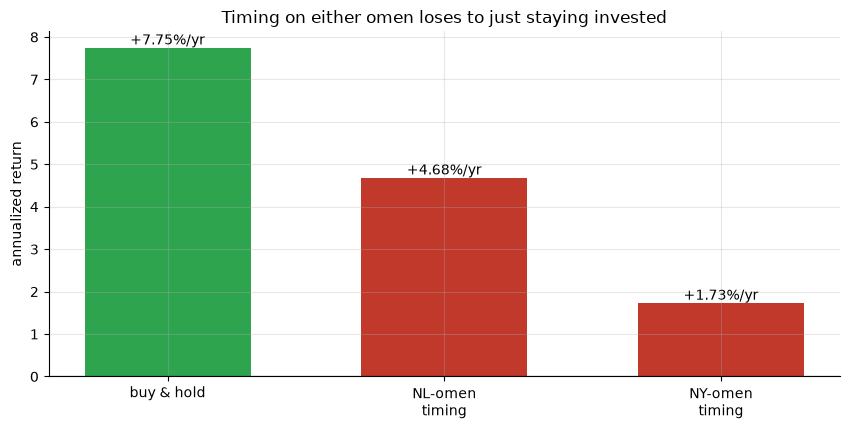

buy-and-hold +7.75%/yr   NL-timing +4.68%/yr   NY-timing +1.73%/yr


In [5]:
if HAVE_REAL:
    t1 = st.timing_strategy(EV, bull_nl); t2 = st.timing_strategy(EV, bull_ny)
    bah, nl_a, ny_a = t1['bah_ann_pct'], t1['strat_ann_pct'], t2['strat_ann_pct']
else:
    bah, nl_a, ny_a = R['bah_ann'], R['nl_strat_ann'], R['ny_strat_ann']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['buy & hold','NL-omen\ntiming','NY-omen\ntiming'], [bah, nl_a, ny_a],
       color=[GREEN, RED, RED], width=.6)
for i,v in enumerate([bah, nl_a, ny_a]): ax.annotate(f'{v:+.2f}%/yr',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualized return')
ax.set_title('Timing on either omen loses to just staying invested')
plt.tight_layout(); plt.show()
print(f'buy-and-hold {bah:+.2f}%/yr   NL-timing {nl_a:+.2f}%/yr   NY-timing {ny_a:+.2f}%/yr')

Sitting in cash whenever an omen says "bearish" means missing chunks of a market that goes up most years — and neither omen has a real signal underneath to pay that back. Both timing strategies lose to simply staying invested, before a single basis point of trading cost.

## 5 · The verdict

- **Signal — None.** Neither the league omen (*t* = 1.07, permutation *p* = 0.30) nor the city omen (*t* = -0.33, and pointing the wrong direction) clears any bar. With 74 seasons split roughly in half, there just isn't enough information in a baseball trophy to move a $40-trillion market.
- **Tradability — Mirage.** Both omen-timing strategies lose to buy-and-hold; sitting out a mostly-up market is expensive and there's no edge to offset it.
- **Beats a coin? — Busted.** Neither omen's hit rate reliably beats a flat 50% coin flip, let alone the market's real 73% up-rate — and the city omen's hit rate is numerically *below* half.

## 6 · Going further 🚪

- **The whole sports-omen family fails the same way.** This desk has now tested football ([158-super-bowl](../../158-super-bowl/)), the Olympics ([234-olympic-year](../../234-olympic-year/)), Eurovision ([708-eurovision-effect](../../708-eurovision-effect/)) and now baseball — all collapse once you check the correct baseline and run a permutation test. The lesson generalizes: an annual calendar event with a binary or small-cardinality label will *always* look mildly correlated with a mostly-up market by chance, and the fix is always the same two checks — the honest base rate, and a shuffle test.
- **A pre-1950 or minor-league extension** could add power, but MLB expansion, league realignments (interleague play since 1997, the Astros' 2013 league switch) make the AL/NL label itself progressively less meaningful the further you push it.

*Think there's a real omen hiding in some other sport's calendar? Show a Welch *t* ≥ 2 against the correct baseline, survive a permutation test, and we'll test it next.*